In [1]:
import json
import random
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from umap import UMAP

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from new.train_embedding_space import embed_texts, load_checkpoint_bundle

DATASET_PATH = ROOT / 'data/ToolCall15/tool_embedding_dataset.jsonl'
CHECKPOINT_PATH = ROOT / 'data/ToolCall15/output/best.pt'
BENCHMARK_PATH = ROOT / 'data/ToolCall15/benchmark.json'
DEVICE = 'cuda:2' if torch.cuda.is_available() else 'cpu'
MAX_SAMPLES = 500
TOP_K_TOOLS = 10
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f'device: {DEVICE}')
print(f'dataset: {DATASET_PATH}')
print(f'checkpoint: {CHECKPOINT_PATH}')


/scratch4/home/akrik/base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda:2
dataset: /scratch4/home/akrik/NTILC/data/ToolCall15/tool_embedding_dataset.jsonl
checkpoint: /scratch4/home/akrik/NTILC/data/ToolCall15/output/best.pt


In [2]:
def load_jsonl(path):
    with path.open('r', encoding='utf-8') as handle:
        return [json.loads(line) for line in handle if line.strip()]


rows = load_jsonl(DATASET_PATH)
random.shuffle(rows)
rows = rows[:MAX_SAMPLES]

bundle = load_checkpoint_bundle(CHECKPOINT_PATH, device=DEVICE)
tool_names = bundle['tool_names']
tool_to_idx = {tool: idx for idx, tool in enumerate(tool_names)}
texts = [row.get('query', row.get('text', '')) for row in rows]
labels = np.array([tool_to_idx[row['tool']] for row in rows])
tool_counts = Counter(row['tool'] for row in rows)

embeddings = embed_texts(
    model=bundle['model'],
    tokenizer=bundle['tokenizer'],
    texts=texts,
    device=DEVICE,
    max_length=bundle['max_length'],
    batch_size=32,
).numpy()
centroids = bundle['centroids'].detach().cpu().numpy()

print(f'samples: {len(rows)}')
print(f'unique tools in sample: {len(tool_counts)}')
print(f'embedding shape: {embeddings.shape}')
print(tool_counts.most_common(10))


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1338.36it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
                                                                 

samples: 144
unique tools in sample: 12
embedding shape: (144, 128)
[('send_email', 12), ('run_code', 12), ('get_contacts', 12), ('search_files', 12), ('read_file', 12), ('create_calendar_event', 12), ('get_stock_price', 12), ('translate_text', 12), ('set_reminder', 12), ('calculator', 12)]


In [3]:
def normalize_matrix(matrix):
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms = np.clip(norms, 1e-12, None)
    return matrix / norms


normalized_embeddings = normalize_matrix(embeddings)
normalized_centroids = normalize_matrix(centroids)
scores = normalized_embeddings @ normalized_centroids.T
predictions = scores.argmax(axis=1)
retrieval_accuracy = float((predictions == labels).mean())

print(f'retrieval accuracy on sample rows: {retrieval_accuracy:.4f}')
if len(np.unique(labels)) > 1:
    sil = silhouette_score(embeddings, labels, metric='cosine')
    print(f'silhouette score: {sil:.4f}')
else:
    print('Need at least two tools for silhouette score.')


retrieval accuracy on sample rows: 0.9722
silhouette score: 0.3356


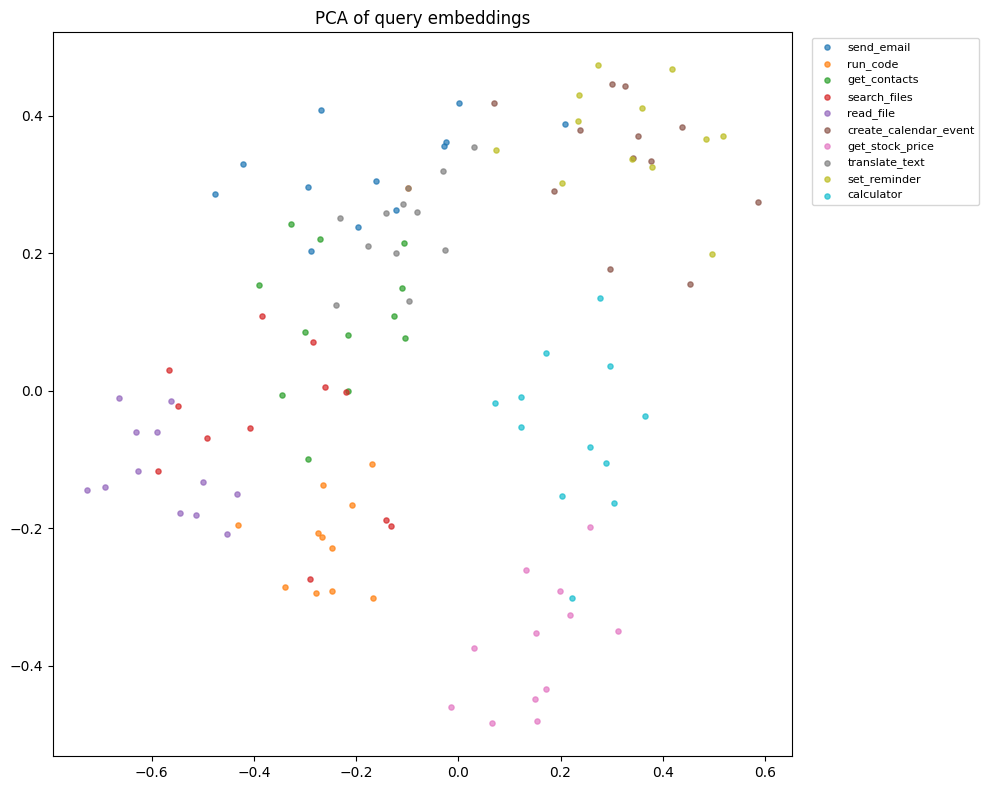

/scratch4/home/akrik/base/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


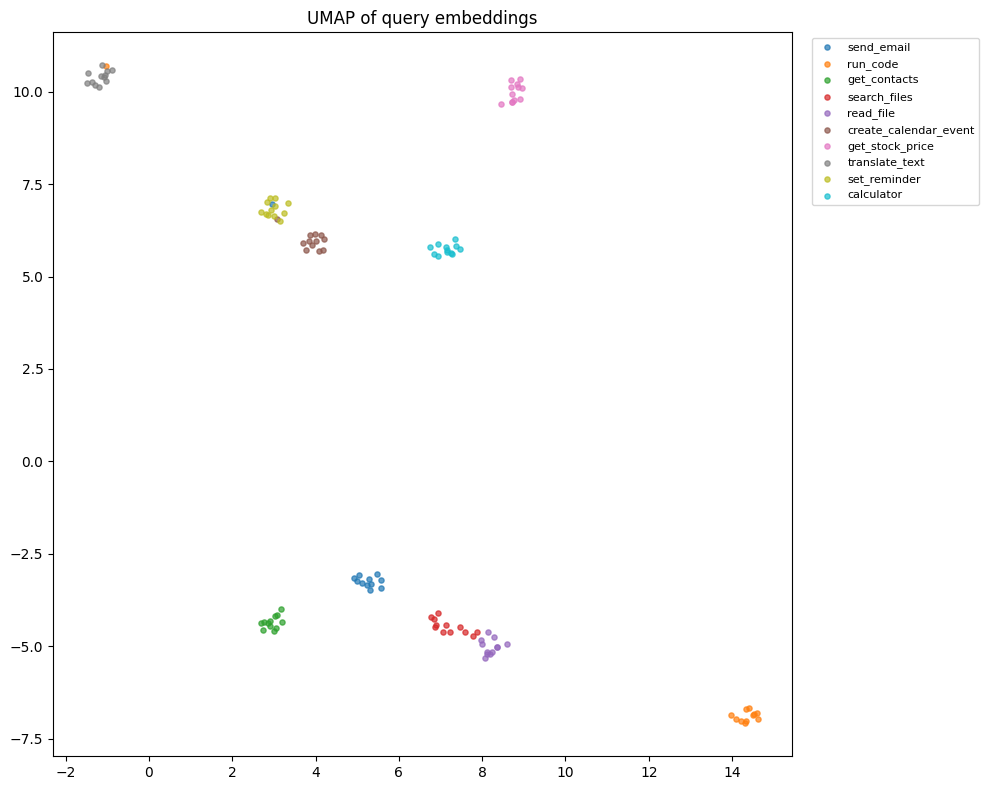

In [4]:
def plot_projection(xy, title):
    top_tools = [tool for tool, _ in tool_counts.most_common(TOP_K_TOOLS)]
    plt.figure(figsize=(10, 8))
    for tool in top_tools:
        idx = [i for i, row in enumerate(rows) if row['tool'] == tool]
        plt.scatter(xy[idx, 0], xy[idx, 1], s=14, alpha=0.7, label=tool)
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()


plot_projection(
    PCA(n_components=2, random_state=SEED).fit_transform(embeddings),
    'PCA of query embeddings',
)

plot_projection(
    UMAP(n_components=2, random_state=SEED).fit_transform(embeddings),
    'UMAP of query embeddings',
)


In [5]:
examples = []
for idx in random.sample(range(len(rows)), min(12, len(rows))):
    top3_idx = scores[idx].argsort()[::-1][:3]
    examples.append(
        {
            'query': rows[idx]['query'],
            'expected_tool': rows[idx]['tool'],
            'predicted_tool': tool_names[int(predictions[idx])],
            'top3_tools': ', '.join(tool_names[i] for i in top3_idx),
        }
    )

pd.DataFrame(examples)


,query,expected_tool,predicted_tool,top3_tools
0,Remind me to water the plants this Monday morning,set_reminder,set_reminder,"set_reminder, send_email, create_calendar_event"
1,I need the latest price for MSFT shares.,get_stock_price,get_stock_price,"get_stock_price, web_search, search_files"
2,What's the value of GOOGL right now?,get_stock_price,get_stock_price,"get_stock_price, web_search, set_reminder"
3,Write to team-lead@startup.io with the subject...,send_email,send_email,"send_email, create_calendar_event, set_reminder"
4,Try running this python loop to see what it ou...,run_code,run_code,"run_code, read_file, send_email"
5,Execute the following javascript logic for str...,run_code,run_code,"run_code, calculator, read_file"
6,Make sure I don't miss the team meeting schedu...,set_reminder,set_reminder,"set_reminder, create_calendar_event, web_search"
7,Schedule a reminder to wake up early at 6 AM t...,set_reminder,set_reminder,"set_reminder, create_calendar_event, web_search"
8,I have a message in Russian that needs to be r...,translate_text,translate_text,"translate_text, send_email, read_file"
9,Search for John's phone number,get_contacts,get_contacts,"get_contacts, search_files, run_code"


In [6]:
with BENCHMARK_PATH.open('r', encoding='utf-8') as handle:
    benchmark = json.load(handle)['scenarios']

benchmark_texts = [item['input'] for item in benchmark]
benchmark_embeddings = embed_texts(
    model=bundle['model'],
    tokenizer=bundle['tokenizer'],
    texts=benchmark_texts,
    device=DEVICE,
    max_length=bundle['max_length'],
    batch_size=32,
).numpy()
benchmark_scores = normalize_matrix(benchmark_embeddings) @ normalized_centroids.T

report = []
for scenario, row_scores in zip(benchmark, benchmark_scores):
    top5_idx = row_scores.argsort()[::-1][:5]
    top5_tools = [tool_names[i] for i in top5_idx]
    expected_tools = scenario.get('expected_tools', [])
    hit_at_5 = any(tool in top5_tools for tool in expected_tools) if expected_tools else None
    report.append(
        {
            'id': scenario['id'],
            'title': scenario['title'],
            'expected_tools': ', '.join(expected_tools),
            'top5_tools': ', '.join(top5_tools),
            'hit@5': hit_at_5,
        }
    )

pd.DataFrame(report)


,id,title,expected_tools,top5_tools,hit@5
0,TC-01,Weather Lookup,get_weather,"get_weather, web_search, set_reminder, calcula...",True
1,TC-02,Stock Lookup,get_stock_price,"get_stock_price, web_search, get_weather, set_...",True
2,TC-03,Implicit Tool Chain,"get_contacts, send_email","set_reminder, create_calendar_event, send_emai...",True
3,TC-04,Unit Handling,get_weather,"get_weather, web_search, calculator, create_ca...",True
4,TC-05,Calendar Parsing,create_calendar_event,"create_calendar_event, set_reminder, web_searc...",True
5,TC-06,Multi Translation,translate_text,"translate_text, web_search, create_calendar_ev...",True
6,TC-07,Search → Read → Email,"search_files, read_file, get_contacts, send_email","search_files, send_email, get_contacts, create...",True
7,TC-08,Conditional Logic,"get_weather, set_reminder","set_reminder, get_weather, web_search, create_...",True
8,TC-09,Parallel Tasks,"get_weather, get_stock_price","get_stock_price, get_weather, web_search, set_...",True
9,TC-10,Basic Knowledge,,"web_search, search_files, get_weather, get_sto...",None
